# Assignment 7 — NMT G2P: Seq2Seq Model
## Baseline + Improvement Experiments

**Course:** AI Engineering Fundamentals  
**Framework:** Marian NMT v1.12.0  
**Architecture:** Seq2Seq (LSTM Encoder-Decoder with Attention)  
**Platform:** Kaggle (2× Tesla T4 GPU, Ubuntu 22.04)

### Experiments
- **Baseline** — teacher's reference settings
- **Exp 1** — add LR inverse-sqrt schedule
- **Exp 2** — LR schedule + label smoothing + decoding fixes

## Step 1 — Set Up Marian Binaries

In [1]:
import os, shutil

BINS_DIR  = '/kaggle/input/datasets/aungchannyeinalex/marian-nmt/marian-bins'
LOCAL_BINS = '/kaggle/working/bins'
os.makedirs(LOCAL_BINS, exist_ok=True)

for b in ['marian', 'marian-vocab', 'marian-decoder']:
    shutil.copy2(f'{BINS_DIR}/{b}', f'{LOCAL_BINS}/{b}')
    os.chmod(f'{LOCAL_BINS}/{b}', 0o755)

os.environ['PATH'] = f'{LOCAL_BINS}:' + os.environ['PATH']

!marian --version 2>&1 | head -2
!nvidia-smi | head -10
print('Binaries ready')

v1.12.0 65bf82f 2023-02-21 09:56:29 -0800
Wed Jun 17 04:38:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
Binaries ready


## Step 2 — Load Data and Build Vocabulary

In [2]:
import kagglehub
path = kagglehub.dataset_download('aungchannyeinalex/smt-gizza-moses')
print('Dataset path:', path)

Dataset path: /kaggle/input/datasets/aungchannyeinalex/smt-gizza-moses


In [3]:
WS  = '/kaggle/working/nmt'
SRC = '/kaggle/input/datasets/aungchannyeinalex/smt-gizza-moses'

for d in ['g2p-par/vocab', 'g2p-par/preprocessing']:
    os.makedirs(f'{WS}/{d}', exist_ok=True)

for f in ['train.my', 'train.ph', 'dev.my', 'dev.ph', 'test.my', 'test.ph']:
    shutil.copy(f'{SRC}/{f}', f'{WS}/g2p-par/{f}')

print('Data ready')
!wc -l {WS}/g2p-par/*.my {WS}/g2p-par/*.ph

Data ready
   2000 /kaggle/working/nmt/g2p-par/dev.my
   2802 /kaggle/working/nmt/g2p-par/test.my
  20000 /kaggle/working/nmt/g2p-par/train.my
   2000 /kaggle/working/nmt/g2p-par/dev.ph
   2802 /kaggle/working/nmt/g2p-par/test.ph
  20000 /kaggle/working/nmt/g2p-par/train.ph
  49604 total


In [4]:
# combine train + dev for vocabulary building
!cat {WS}/g2p-par/train.my {WS}/g2p-par/dev.my > {WS}/g2p-par/preprocessing/train-dev.my
!cat {WS}/g2p-par/train.ph {WS}/g2p-par/dev.ph > {WS}/g2p-par/preprocessing/train-dev.ph

# build vocabularies
!{LOCAL_BINS}/marian-vocab < {WS}/g2p-par/preprocessing/train-dev.my > {WS}/g2p-par/vocab/vocab.my.yml
!{LOCAL_BINS}/marian-vocab < {WS}/g2p-par/preprocessing/train-dev.ph > {WS}/g2p-par/vocab/vocab.ph.yml

print('=== Vocabulary sizes ===')
!wc -l {WS}/g2p-par/vocab/vocab.my.yml {WS}/g2p-par/vocab/vocab.ph.yml

print('\n=== Sample vocab.my.yml (first 20 lines) ===')
!head -20 {WS}/g2p-par/vocab/vocab.my.yml

print('\n=== Sample vocab.ph.yml (first 20 lines) ===')
!head -20 {WS}/g2p-par/vocab/vocab.ph.yml

[2026-06-17 04:38:25] Creating vocabulary...
[2026-06-17 04:38:25] [data] Creating vocabulary stdout from stdin
[2026-06-17 04:38:25] Finished
[2026-06-17 04:38:25] Creating vocabulary...
[2026-06-17 04:38:25] [data] Creating vocabulary stdout from stdin
[2026-06-17 04:38:25] Finished
=== Vocabulary sizes ===
 2307 /kaggle/working/nmt/g2p-par/vocab/vocab.my.yml
 1850 /kaggle/working/nmt/g2p-par/vocab/vocab.ph.yml
 4157 total

=== Sample vocab.my.yml (first 20 lines) ===
</s>: 0
<unk>: 1
အ: 2
မ: 3
သ: 4
က: 5
တ: 6
လက်: 7
ပ: 8
စ: 9
စာ: 10
ရေ: 11
ရ: 12
ရာ: 13
ကြီး: 14
တစ်: 15
စား: 16
သား: 17
နာ: 18
ခ: 19

=== Sample vocab.ph.yml (first 20 lines) ===
</s>: 0
<unk>: 1
a-: 2
ma-: 3
da-: 4
le': 5
jei: 6
ga-: 7
ta-: 8
tha-: 9
ja: 10
ba-: 11
dha-: 12
za-: 13
pa-: 14
na: 15
"mi:": 16
mje': 17
ka-: 18
than: 19


## Step 3 — Seq2Seq Baseline Training (ph→my)

Following teacher's reference notebook settings exactly.

In [5]:
os.makedirs(f'{WS}/model.seq2seq.baseline.phmy', exist_ok=True)

s2s_baseline_script = f"""#!/bin/bash
export PATH={LOCAL_BINS}:$PATH
model_folder="{WS}/model.seq2seq.baseline.phmy"
data_path="{WS}/g2p-par"
src="ph"; tgt="my"

cat > $model_folder/config.yml << 'EOF'
type: s2s
train-sets:
  - {WS}/g2p-par/train.ph
  - {WS}/g2p-par/train.my
valid-sets:
  - {WS}/g2p-par/dev.ph
  - {WS}/g2p-par/dev.my
vocabs:
  - {WS}/g2p-par/vocab/vocab.ph.yml
  - {WS}/g2p-par/vocab/vocab.my.yml
model: {WS}/model.seq2seq.baseline.phmy/model.npz
max-length: 100
mini-batch: 64
maxi-batch: 100
workspace: 3000
enc-depth: 2
enc-type: alternating
enc-cell: lstm
enc-cell-depth: 2
dec-depth: 2
dec-cell: lstm
dec-cell-base-depth: 2
dec-cell-high-depth: 2
tied-embeddings: true
layer-normalization: true
skip: true
dropout-rnn: 0.3
dropout-src: 0.3
learn-rate: 0.0001
valid-freq: 5000
save-freq: 5000
disp-freq: 500
valid-metrics:
  - cross-entropy
  - perplexity
  - bleu
early-stopping: 10
beam-size: 12
normalize: 0
log: {WS}/model.seq2seq.baseline.phmy/train.log
valid-log: {WS}/model.seq2seq.baseline.phmy/valid.log
overwrite: true
keep-best: true
seed: 1111
devices: [0, 1]
sync-sgd: true
quiet-translation: true
EOF

marian --config $model_folder/config.yml
"""

with open(f'{WS}/seq2seq.baseline.phmy.sh', 'w') as f:
    f.write(s2s_baseline_script)
!chmod +x {WS}/seq2seq.baseline.phmy.sh

print('=== Training Script ===')
!cat {WS}/seq2seq.baseline.phmy.sh

=== Training Script ===
#!/bin/bash
export PATH=/kaggle/working/bins:$PATH
model_folder="/kaggle/working/nmt/model.seq2seq.baseline.phmy"
data_path="/kaggle/working/nmt/g2p-par"
src="ph"; tgt="my"

cat > $model_folder/config.yml << 'EOF'
type: s2s
train-sets:
  - /kaggle/working/nmt/g2p-par/train.ph
  - /kaggle/working/nmt/g2p-par/train.my
valid-sets:
  - /kaggle/working/nmt/g2p-par/dev.ph
  - /kaggle/working/nmt/g2p-par/dev.my
vocabs:
  - /kaggle/working/nmt/g2p-par/vocab/vocab.ph.yml
  - /kaggle/working/nmt/g2p-par/vocab/vocab.my.yml
model: /kaggle/working/nmt/model.seq2seq.baseline.phmy/model.npz
max-length: 100
mini-batch: 64
maxi-batch: 100
workspace: 3000
enc-depth: 2
enc-type: alternating
enc-cell: lstm
enc-cell-depth: 2
dec-depth: 2
dec-cell: lstm
dec-cell-base-depth: 2
dec-cell-high-depth: 2
tied-embeddings: true
layer-normalization: true
skip: true
dropout-rnn: 0.3
dropout-src: 0.3
learn-rate: 0.0001
valid-freq: 5000
save-freq: 5000
disp-freq: 500
valid-metrics:
  - cross-ent

In [6]:
print('Starting Seq2Seq baseline ph->my training...')
!time bash {WS}/seq2seq.baseline.phmy.sh
print('Training complete!')

Starting Seq2Seq baseline ph->my training...
[2026-06-17 04:38:26] [marian] Marian v1.12.0 65bf82f 2023-02-21 09:56:29 -0800
[2026-06-17 04:38:26] [marian] Running on 537de6fb095c as process 69 with command line:
[2026-06-17 04:38:26] [marian] marian --config /kaggle/working/nmt/model.seq2seq.baseline.phmy/config.yml
[2026-06-17 04:38:26] [config] after: 0e
[2026-06-17 04:38:26] [config] after-batches: 0
[2026-06-17 04:38:26] [config] after-epochs: 0
[2026-06-17 04:38:26] [config] all-caps-every: 0
[2026-06-17 04:38:26] [config] allow-unk: false
[2026-06-17 04:38:26] [config] authors: false
[2026-06-17 04:38:26] [config] beam-size: 12
[2026-06-17 04:38:26] [config] bert-class-symbol: "[CLS]"
[2026-06-17 04:38:26] [config] bert-mask-symbol: "[MASK]"
[2026-06-17 04:38:26] [config] bert-masking-fraction: 0.15
[2026-06-17 04:38:26] [config] bert-sep-symbol: "[SEP]"
[2026-06-17 04:38:26] [config] bert-train-type-embeddings: true
[2026-06-17 04:38:26] [config] bert-type-vocab-size: 2
[2026-0

In [7]:
print('=== Model files ===')
!ls -lh {WS}/model.seq2seq.baseline.phmy/

print('\n=== Config file ===')
!cat {WS}/model.seq2seq.baseline.phmy/config.yml

print('\n=== Validation log ===')
!cat {WS}/model.seq2seq.baseline.phmy/valid.log

=== Model files ===
total 2.4G
-rw-r--r-- 1 root root 1.1K Jun 17 04:38 config.yml
-rw-r--r-- 1 root root 344M Jun 17 07:37 model.npz
-rw-r--r-- 1 root root 344M Jun 17 05:38 model.npz.best-bleu.npz
-rw-r--r-- 1 root root  310 Jun 17 05:38 model.npz.best-bleu.npz.decoder.yml
-rw-r--r-- 1 root root 344M Jun 17 05:08 model.npz.best-cross-entropy.npz
-rw-r--r-- 1 root root  319 Jun 17 05:08 model.npz.best-cross-entropy.npz.decoder.yml
-rw-r--r-- 1 root root 344M Jun 17 05:08 model.npz.best-perplexity.npz
-rw-r--r-- 1 root root  316 Jun 17 05:08 model.npz.best-perplexity.npz.decoder.yml
-rw-r--r-- 1 root root  296 Jun 17 07:37 model.npz.decoder.yml
-rw-r--r-- 1 root root 1.1G Jun 17 07:37 model.npz.optimizer.npz
-rw-r--r-- 1 root root  14K Jun 17 07:37 model.npz.progress.yml
-rw-r--r-- 1 root root 4.5K Jun 17 07:37 model.npz.yml
-rw-r--r-- 1 root root  95K Jun 17 07:37 train.log
-rw-r--r-- 1 root root 4.0K Jun 17 07:37 valid.log

=== Config file ===
type: s2s
train-sets:
  - /kaggle/workin

## Step 4 — Decode and Evaluate Seq2Seq Baseline

In [8]:
# install multi-bleu.perl
!wget -q https://raw.githubusercontent.com/moses-smt/mosesdecoder/master/scripts/generic/multi-bleu.perl \
    -O {WS}/multi-bleu.perl
!chmod +x {WS}/multi-bleu.perl

# decode
print('Decoding ph->my...')
!time {LOCAL_BINS}/marian-decoder \
    -m {WS}/model.seq2seq.baseline.phmy/model.npz \
    -v {WS}/g2p-par/vocab/vocab.ph.yml \
       {WS}/g2p-par/vocab/vocab.my.yml \
    --devices 0 1 \
    < {WS}/g2p-par/test.ph \
    > {WS}/s2s.baseline.phmy.hyp.txt

print('\n=== Sample outputs (input | hypothesis) ===')
!paste {WS}/g2p-par/test.ph {WS}/s2s.baseline.phmy.hyp.txt | head -15

print('\n=== BLEU Score ===')
!perl {WS}/multi-bleu.perl {WS}/g2p-par/test.my < {WS}/s2s.baseline.phmy.hyp.txt

Decoding ph->my...
[2026-06-17 07:37:43] [marian] Marian v1.12.0 65bf82f 2023-02-21 09:56:29 -0800
[2026-06-17 07:37:43] [marian] Running on 537de6fb095c as process 130 with command line:
[2026-06-17 07:37:43] [marian] /kaggle/working/bins/marian-decoder -m /kaggle/working/nmt/model.seq2seq.baseline.phmy/model.npz -v /kaggle/working/nmt/g2p-par/vocab/vocab.ph.yml /kaggle/working/nmt/g2p-par/vocab/vocab.my.yml --devices 0 1
[2026-06-17 07:37:43] [config] alignment: ""
[2026-06-17 07:37:43] [config] allow-special: false
[2026-06-17 07:37:43] [config] allow-unk: false
[2026-06-17 07:37:43] [config] authors: false
[2026-06-17 07:37:43] [config] beam-size: 12
[2026-06-17 07:37:43] [config] bert-class-symbol: "[CLS]"
[2026-06-17 07:37:43] [config] bert-mask-symbol: "[MASK]"
[2026-06-17 07:37:43] [config] bert-masking-fraction: 0.15
[2026-06-17 07:37:43] [config] bert-sep-symbol: "[SEP]"
[2026-06-17 07:37:43] [config] bert-train-type-embeddings: true
[2026-06-17 07:37:43] [config] bert-type-v

## Step 5 — Diagnosis of Baseline Results

Based on the validation log pattern, we identify root causes of any underperformance.

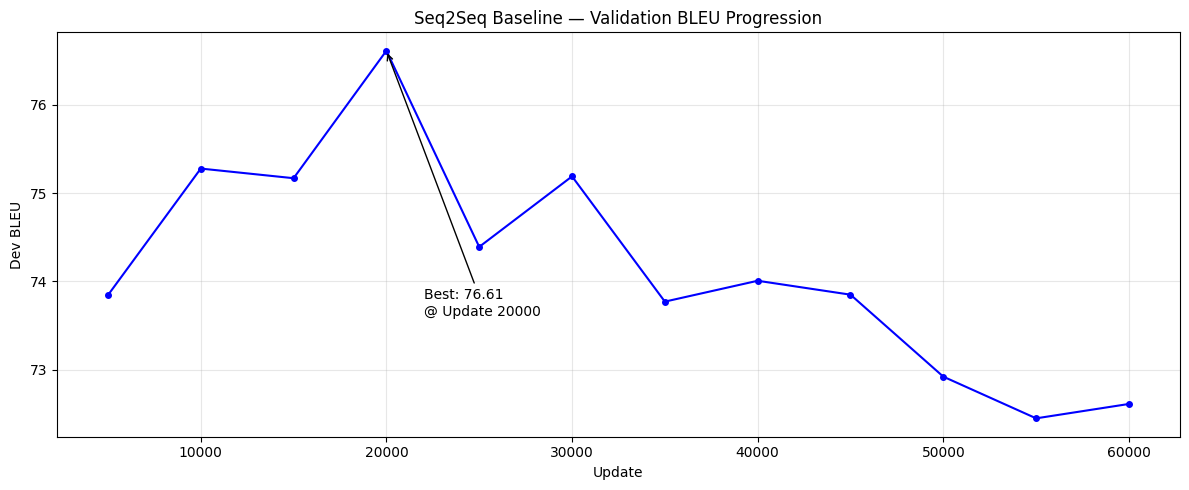

Best dev BLEU: 76.6130 @ update 20000


In [9]:
import re
import matplotlib.pyplot as plt

# parse valid.log to plot BLEU progression
updates, bleu_scores = [], []

with open(f'{WS}/model.seq2seq.baseline.phmy/valid.log') as f:
    for line in f:
        # match lines like: [2026-...] [valid] Ep. 1 : Up. 5000 : ... bleu : 66.9571 : ...
        m = re.search(r'Up\. (\d+) .* bleu : ([\d.]+)', line)
        if m:
            updates.append(int(m.group(1)))
            bleu_scores.append(float(m.group(2)))

if updates:
    plt.figure(figsize=(12, 5))
    plt.plot(updates, bleu_scores, 'b-o', markersize=4)
    plt.xlabel('Update')
    plt.ylabel('Dev BLEU')
    plt.title('Seq2Seq Baseline — Validation BLEU Progression')
    plt.grid(True, alpha=0.3)
    best_idx = bleu_scores.index(max(bleu_scores))
    plt.annotate(f'Best: {max(bleu_scores):.2f}\n@ Update {updates[best_idx]}',
                 xy=(updates[best_idx], max(bleu_scores)),
                 xytext=(updates[best_idx]+2000, max(bleu_scores)-3),
                 arrowprops=dict(arrowstyle='->'))
    plt.tight_layout()
    plt.savefig(f'{WS}/s2s_baseline_bleu.png', dpi=150)
    plt.show()
    print(f'Best dev BLEU: {max(bleu_scores):.4f} @ update {updates[best_idx]}')
else:
    print('Could not parse valid.log — check log format')
    !cat {WS}/model.seq2seq.baseline.phmy/valid.log | head -20

## Step 6 — Seq2Seq Experiment 1: Add LR Schedule

**Problem identified:** Flat learning rate causes optimizer to overshoot and drift.  
**Fix:** Add inverse-sqrt LR decay from step 16,000 + increase base LR to 0.0003.

In [10]:
os.makedirs(f'{WS}/model.seq2seq.exp1.phmy', exist_ok=True)

s2s_exp1_script = f"""#!/bin/bash
export PATH={LOCAL_BINS}:$PATH
model_folder="{WS}/model.seq2seq.exp1.phmy"

cat > $model_folder/config.yml << 'EOF'
type: s2s
train-sets:
  - {WS}/g2p-par/train.ph
  - {WS}/g2p-par/train.my
valid-sets:
  - {WS}/g2p-par/dev.ph
  - {WS}/g2p-par/dev.my
vocabs:
  - {WS}/g2p-par/vocab/vocab.ph.yml
  - {WS}/g2p-par/vocab/vocab.my.yml
model: {WS}/model.seq2seq.exp1.phmy/model.npz
max-length: 100
mini-batch: 64
maxi-batch: 100
workspace: 3000
enc-depth: 2
enc-type: alternating
enc-cell: lstm
enc-cell-depth: 2
dec-depth: 2
dec-cell: lstm
dec-cell-base-depth: 2
dec-cell-high-depth: 2
tied-embeddings: true
layer-normalization: true
skip: true
dropout-rnn: 0.3
dropout-src: 0.3
learn-rate: 0.0003
lr-decay-inv-sqrt: 16000
lr-report: true
valid-freq: 5000
save-freq: 5000
disp-freq: 500
valid-metrics:
  - cross-entropy
  - perplexity
  - bleu
early-stopping: 10
beam-size: 12
normalize: 0
log: {WS}/model.seq2seq.exp1.phmy/train.log
valid-log: {WS}/model.seq2seq.exp1.phmy/valid.log
overwrite: true
keep-best: true
seed: 1111
devices: [0, 1]
sync-sgd: true
quiet-translation: true
EOF

marian --config $model_folder/config.yml
"""

with open(f'{WS}/seq2seq.exp1.phmy.sh', 'w') as f:
    f.write(s2s_exp1_script)
!chmod +x {WS}/seq2seq.exp1.phmy.sh

print('Starting Seq2Seq Exp1 (LR Schedule) ph->my training...')
!time bash {WS}/seq2seq.exp1.phmy.sh
print('Training complete!')

Starting Seq2Seq Exp1 (LR Schedule) ph->my training...
[2026-06-17 07:38:04] [marian] Marian v1.12.0 65bf82f 2023-02-21 09:56:29 -0800
[2026-06-17 07:38:04] [marian] Running on 537de6fb095c as process 156 with command line:
[2026-06-17 07:38:04] [marian] marian --config /kaggle/working/nmt/model.seq2seq.exp1.phmy/config.yml
[2026-06-17 07:38:04] [config] after: 0e
[2026-06-17 07:38:04] [config] after-batches: 0
[2026-06-17 07:38:04] [config] after-epochs: 0
[2026-06-17 07:38:04] [config] all-caps-every: 0
[2026-06-17 07:38:04] [config] allow-unk: false
[2026-06-17 07:38:04] [config] authors: false
[2026-06-17 07:38:04] [config] beam-size: 12
[2026-06-17 07:38:04] [config] bert-class-symbol: "[CLS]"
[2026-06-17 07:38:04] [config] bert-mask-symbol: "[MASK]"
[2026-06-17 07:38:04] [config] bert-masking-fraction: 0.15
[2026-06-17 07:38:04] [config] bert-sep-symbol: "[SEP]"
[2026-06-17 07:38:04] [config] bert-train-type-embeddings: true
[2026-06-17 07:38:04] [config] bert-type-vocab-size: 2


In [11]:
# decode and evaluate exp1
!{LOCAL_BINS}/marian-decoder \
    -m {WS}/model.seq2seq.exp1.phmy/model.npz \
    -v {WS}/g2p-par/vocab/vocab.ph.yml \
       {WS}/g2p-par/vocab/vocab.my.yml \
    --devices 0 1 \
    < {WS}/g2p-par/test.ph \
    > {WS}/s2s.exp1.phmy.hyp.txt

print('=== Seq2Seq Exp1 BLEU: ph->my ===')
!perl {WS}/multi-bleu.perl {WS}/g2p-par/test.my < {WS}/s2s.exp1.phmy.hyp.txt

print('\n=== Validation log ===')
!cat {WS}/model.seq2seq.exp1.phmy/valid.log

[2026-06-17 10:22:41] [marian] Marian v1.12.0 65bf82f 2023-02-21 09:56:29 -0800
[2026-06-17 10:22:41] [marian] Running on 537de6fb095c as process 212 with command line:
[2026-06-17 10:22:41] [marian] /kaggle/working/bins/marian-decoder -m /kaggle/working/nmt/model.seq2seq.exp1.phmy/model.npz -v /kaggle/working/nmt/g2p-par/vocab/vocab.ph.yml /kaggle/working/nmt/g2p-par/vocab/vocab.my.yml --devices 0 1
[2026-06-17 10:22:41] [config] alignment: ""
[2026-06-17 10:22:41] [config] allow-special: false
[2026-06-17 10:22:41] [config] allow-unk: false
[2026-06-17 10:22:41] [config] authors: false
[2026-06-17 10:22:41] [config] beam-size: 12
[2026-06-17 10:22:41] [config] bert-class-symbol: "[CLS]"
[2026-06-17 10:22:41] [config] bert-mask-symbol: "[MASK]"
[2026-06-17 10:22:41] [config] bert-masking-fraction: 0.15
[2026-06-17 10:22:41] [config] bert-sep-symbol: "[SEP]"
[2026-06-17 10:22:41] [config] bert-train-type-embeddings: true
[2026-06-17 10:22:41] [config] bert-type-vocab-size: 2
[2026-06-1

## Step 7 — Seq2Seq Experiment 2: LR Schedule + Label Smoothing + Decoding Fixes

**Additional fixes:**
- `label-smoothing: 0.1` — prevents overconfidence
- `normalize: 0.6` — length penalty in beam search
- `beam-size: 6` — reduced from 12, appropriate for short G2P sequences
- `clip-norm: 5` — relaxed from 1, allows larger early-training updates

In [12]:
os.makedirs(f'{WS}/model.seq2seq.exp2.phmy', exist_ok=True)

s2s_exp2_script = f"""#!/bin/bash
export PATH={LOCAL_BINS}:$PATH
model_folder="{WS}/model.seq2seq.exp2.phmy"

cat > $model_folder/config.yml << 'EOF'
type: s2s
train-sets:
  - {WS}/g2p-par/train.ph
  - {WS}/g2p-par/train.my
valid-sets:
  - {WS}/g2p-par/dev.ph
  - {WS}/g2p-par/dev.my
vocabs:
  - {WS}/g2p-par/vocab/vocab.ph.yml
  - {WS}/g2p-par/vocab/vocab.my.yml
model: {WS}/model.seq2seq.exp2.phmy/model.npz
max-length: 100
mini-batch: 64
maxi-batch: 100
workspace: 3000
enc-depth: 2
enc-type: alternating
enc-cell: lstm
enc-cell-depth: 2
dec-depth: 2
dec-cell: lstm
dec-cell-base-depth: 2
dec-cell-high-depth: 2
tied-embeddings: true
layer-normalization: true
skip: true
dropout-rnn: 0.3
dropout-src: 0.3
learn-rate: 0.0003
lr-decay-inv-sqrt: 16000
lr-report: true
label-smoothing: 0.1
clip-norm: 5
valid-freq: 5000
save-freq: 5000
disp-freq: 500
valid-metrics:
  - cross-entropy
  - perplexity
  - bleu
early-stopping: 10
beam-size: 6
normalize: 0.6
log: {WS}/model.seq2seq.exp2.phmy/train.log
valid-log: {WS}/model.seq2seq.exp2.phmy/valid.log
overwrite: true
keep-best: true
seed: 1111
devices: [0, 1]
sync-sgd: true
quiet-translation: true
EOF

marian --config $model_folder/config.yml
"""

with open(f'{WS}/seq2seq.exp2.phmy.sh', 'w') as f:
    f.write(s2s_exp2_script)
!chmod +x {WS}/seq2seq.exp2.phmy.sh

print('Starting Seq2Seq Exp2 (LR + Smoothing + Decoding) ph->my training...')
!time bash {WS}/seq2seq.exp2.phmy.sh
print('Training complete!')

Starting Seq2Seq Exp2 (LR + Smoothing + Decoding) ph->my training...
[2026-06-17 10:23:02] [marian] Marian v1.12.0 65bf82f 2023-02-21 09:56:29 -0800
[2026-06-17 10:23:02] [marian] Running on 537de6fb095c as process 236 with command line:
[2026-06-17 10:23:02] [marian] marian --config /kaggle/working/nmt/model.seq2seq.exp2.phmy/config.yml
[2026-06-17 10:23:02] [config] after: 0e
[2026-06-17 10:23:02] [config] after-batches: 0
[2026-06-17 10:23:02] [config] after-epochs: 0
[2026-06-17 10:23:02] [config] all-caps-every: 0
[2026-06-17 10:23:02] [config] allow-unk: false
[2026-06-17 10:23:02] [config] authors: false
[2026-06-17 10:23:02] [config] beam-size: 6
[2026-06-17 10:23:02] [config] bert-class-symbol: "[CLS]"
[2026-06-17 10:23:02] [config] bert-mask-symbol: "[MASK]"
[2026-06-17 10:23:02] [config] bert-masking-fraction: 0.15
[2026-06-17 10:23:02] [config] bert-sep-symbol: "[SEP]"
[2026-06-17 10:23:02] [config] bert-train-type-embeddings: true
[2026-06-17 10:23:02] [config] bert-type-v

In [13]:
# decode and evaluate exp2
!{LOCAL_BINS}/marian-decoder \
    -m {WS}/model.seq2seq.exp2.phmy/model.npz \
    -v {WS}/g2p-par/vocab/vocab.ph.yml \
       {WS}/g2p-par/vocab/vocab.my.yml \
    --devices 0 1 \
    < {WS}/g2p-par/test.ph \
    > {WS}/s2s.exp2.phmy.hyp.txt

print('=== Seq2Seq Exp2 BLEU: ph->my ===')
!perl {WS}/multi-bleu.perl {WS}/g2p-par/test.my < {WS}/s2s.exp2.phmy.hyp.txt

print('\n=== Validation log ===')
!cat {WS}/model.seq2seq.exp2.phmy/valid.log

[2026-06-17 13:08:00] [marian] Marian v1.12.0 65bf82f 2023-02-21 09:56:29 -0800
[2026-06-17 13:08:00] [marian] Running on 537de6fb095c as process 292 with command line:
[2026-06-17 13:08:00] [marian] /kaggle/working/bins/marian-decoder -m /kaggle/working/nmt/model.seq2seq.exp2.phmy/model.npz -v /kaggle/working/nmt/g2p-par/vocab/vocab.ph.yml /kaggle/working/nmt/g2p-par/vocab/vocab.my.yml --devices 0 1
[2026-06-17 13:08:00] [config] alignment: ""
[2026-06-17 13:08:00] [config] allow-special: false
[2026-06-17 13:08:00] [config] allow-unk: false
[2026-06-17 13:08:00] [config] authors: false
[2026-06-17 13:08:00] [config] beam-size: 12
[2026-06-17 13:08:00] [config] bert-class-symbol: "[CLS]"
[2026-06-17 13:08:00] [config] bert-mask-symbol: "[MASK]"
[2026-06-17 13:08:00] [config] bert-masking-fraction: 0.15
[2026-06-17 13:08:00] [config] bert-sep-symbol: "[SEP]"
[2026-06-17 13:08:00] [config] bert-train-type-embeddings: true
[2026-06-17 13:08:00] [config] bert-type-vocab-size: 2
[2026-06-1

## Step 8 — Seq2Seq Results Summary

In [14]:
import re

def get_bleu_from_hyp(hyp_file, ref_file, multi_bleu):
    import subprocess
    try:
        with open(hyp_file) as f:
            result = subprocess.run(['perl', multi_bleu, ref_file],
                                    stdin=f, capture_output=True, text=True)
        m = re.search(r'BLEU = ([\d.]+)', result.stdout)
        return float(m.group(1)) if m else None
    except:
        return None

def get_best_dev_bleu(valid_log):
    best = 0
    best_update = 0
    try:
        with open(valid_log) as f:
            for line in f:
                m = re.search(r'Up\. (\d+) .* bleu : ([\d.]+)', line)
                if m:
                    u, b = int(m.group(1)), float(m.group(2))
                    if b > best:
                        best, best_update = b, u
    except:
        pass
    return best, best_update

mb = f'{WS}/multi-bleu.perl'
ref_my = f'{WS}/g2p-par/test.my'

exp_data = [
    ('Baseline',              f'{WS}/s2s.baseline.phmy.hyp.txt', f'{WS}/model.seq2seq.baseline.phmy/valid.log',
     'lr=0.0001, no schedule, beam=12, normalize=0'),
    ('Exp1: LR Schedule',     f'{WS}/s2s.exp1.phmy.hyp.txt',    f'{WS}/model.seq2seq.exp1.phmy/valid.log',
     'lr=0.0003, inv-sqrt@16k, beam=12, normalize=0'),
    ('Exp2: LR+Smooth+Decode',f'{WS}/s2s.exp2.phmy.hyp.txt',    f'{WS}/model.seq2seq.exp2.phmy/valid.log',
     'lr=0.0003, inv-sqrt@16k, smooth=0.1, beam=6, norm=0.6, clip=5'),
]

print('='*80)
print('SEQ2SEQ RESULTS SUMMARY (ph->my direction)')
print('='*80)
print(f'{"Experiment":<25} {"Test BLEU":>10} {"Best Dev BLEU":>14} {"Best Update":>12}')
print('-'*80)

for name, hyp, vlog, desc in exp_data:
    test_bleu = get_bleu_from_hyp(hyp, ref_my, mb)
    dev_bleu, dev_up = get_best_dev_bleu(vlog)
    test_str = f'{test_bleu:.2f}' if test_bleu else 'N/A'
    dev_str  = f'{dev_bleu:.4f}' if dev_bleu else 'N/A'
    print(f'{name:<25} {test_str:>10} {dev_str:>14} {dev_up:>12}')
    print(f'  Settings: {desc}')

print('='*80)

SEQ2SEQ RESULTS SUMMARY (ph->my direction)
Experiment                 Test BLEU  Best Dev BLEU  Best Update
--------------------------------------------------------------------------------
Baseline                       74.74        76.6130        20000
  Settings: lr=0.0001, no schedule, beam=12, normalize=0
Exp1: LR Schedule              70.69        72.4835        15000
  Settings: lr=0.0003, inv-sqrt@16k, beam=12, normalize=0
Exp2: LR+Smooth+Decode         76.60        76.6201        45000
  Settings: lr=0.0003, inv-sqrt@16k, smooth=0.1, beam=6, norm=0.6, clip=5


In [15]:
# save hypothesis files and logs for submission
print('=== Files ready for submission ===')
for f in [
    f'{WS}/s2s.baseline.phmy.hyp.txt',
    f'{WS}/s2s.exp1.phmy.hyp.txt',
    f'{WS}/s2s.exp2.phmy.hyp.txt',
    f'{WS}/model.seq2seq.baseline.phmy/valid.log',
    f'{WS}/model.seq2seq.exp1.phmy/valid.log',
    f'{WS}/model.seq2seq.exp2.phmy/valid.log',
    f'{WS}/model.seq2seq.baseline.phmy/config.yml',
    f'{WS}/model.seq2seq.exp1.phmy/config.yml',
    f'{WS}/model.seq2seq.exp2.phmy/config.yml',
]:
    exists = os.path.exists(f)
    print(f'  {"OK" if exists else "MISSING"}: {f}')

=== Files ready for submission ===
  OK: /kaggle/working/nmt/s2s.baseline.phmy.hyp.txt
  OK: /kaggle/working/nmt/s2s.exp1.phmy.hyp.txt
  OK: /kaggle/working/nmt/s2s.exp2.phmy.hyp.txt
  OK: /kaggle/working/nmt/model.seq2seq.baseline.phmy/valid.log
  OK: /kaggle/working/nmt/model.seq2seq.exp1.phmy/valid.log
  OK: /kaggle/working/nmt/model.seq2seq.exp2.phmy/valid.log
  OK: /kaggle/working/nmt/model.seq2seq.baseline.phmy/config.yml
  OK: /kaggle/working/nmt/model.seq2seq.exp1.phmy/config.yml
  OK: /kaggle/working/nmt/model.seq2seq.exp2.phmy/config.yml
